#### <FONT size="10pt"> <center>Notebook 01 - Exploration, DataViz et Preprocessing</center></FONT>

## **Projet Rakuten - Classification multimodale de produits e-commerce**

**Contexte**  
Ce notebook constitue le premier rendu du projet Rakuten France Multimodal Product Data Classification.  
L'objectif est d'explorer le jeu de données, d'en comprendre la structure et les caractéristiques,  
de produire des visualisations pertinentes et de préparer les données pour la modélisation.

**Auteurs :**  Khoty WOLIR
**Date :** Mars 2026  
**Kernel :** Python (rakuten_env)

## 1. Configuration et imports 

In [1]:
# Chemins du projet
import os

# Répertoire racine du projet
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_RAW_DIR    = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_PROC_DIR   = os.path.join(PROJECT_ROOT, "data", "processed")
FIGURES_DIR     = os.path.join(PROJECT_ROOT, "reports", "figures")
IMAGE_TRAIN_DIR = os.path.join(DATA_RAW_DIR, "image_train")
IMAGE_TEST_DIR  = os.path.join(DATA_RAW_DIR, "image_test")

# Fichiers CSV
X_TRAIN_PATH = os.path.join(DATA_RAW_DIR, "X_train_update.csv")
Y_TRAIN_PATH = os.path.join(DATA_RAW_DIR, "Y_train_CVw08PX.csv")

# X_test est réservé à la phase d'évaluation finale du modèle.
# Il ne sera pas utilisé dans ce notebook (consigne encadrants).
X_TEST_PATH  = os.path.join(DATA_RAW_DIR, "X_test_update.csv")

# Création du dossier figures s'il n'existe pas encore
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Chemins configurés :")
for name, path in {
    "DATA_RAW_DIR": DATA_RAW_DIR,
    "FIGURES_DIR": FIGURES_DIR,
    "X_TRAIN_PATH": X_TRAIN_PATH,
    "Y_TRAIN_PATH": Y_TRAIN_PATH,
}.items():
    print(f"  {name}: {path}")

Chemins configurés :
  DATA_RAW_DIR: C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\raw
  FIGURES_DIR: C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\reports\figures
  X_TRAIN_PATH: C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\raw\X_train_update.csv
  Y_TRAIN_PATH: C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\raw\Y_train_CVw08PX.csv


In [2]:
# Imports généraux
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image

# NLP
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

# Détection de langue
from langdetect import detect, LangDetectException

# Réduction dimensionnelle et clustering
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Métriques
from sklearn.metrics import adjusted_rand_score

# Utilitaires
from tqdm import tqdm

# Paramètres d'affichage
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 100)
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

# Téléchargement des ressources NLTK nécessaires
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

print("Imports OK")

Imports OK


## 2. Chargement des données

In [3]:
# Chargement des fichiers CSV
X_train = pd.read_csv(X_TRAIN_PATH, index_col=0)
Y_train = pd.read_csv(Y_TRAIN_PATH, index_col=0)

# Fusion en un seul DataFrame de travail
df = X_train.copy()
df["prdtypecode"] = Y_train["prdtypecode"]

print(f"X_train : {X_train.shape[0]} lignes, {X_train.shape[1]} colonnes")
print(f"Y_train : {Y_train.shape[0]} lignes, {Y_train.shape[1]} colonnes")
print(f"DataFrame fusionné : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nAperçu des index - X_train min: {X_train.index.min()}, max: {X_train.index.max()}")
print(f"Aperçu des index - Y_train min: {Y_train.index.min()}, max: {Y_train.index.max()}")
print(f"\nCorrespondance des index X/Y : {(X_train.index == Y_train.index).all()}")

X_train : 84916 lignes, 4 colonnes
Y_train : 84916 lignes, 1 colonnes
DataFrame fusionné : 84916 lignes, 5 colonnes

Colonnes : ['designation', 'description', 'productid', 'imageid', 'prdtypecode']

Aperçu des index - X_train min: 0, max: 84915
Aperçu des index - Y_train min: 0, max: 84915

Correspondance des index X/Y : True


In [4]:
# Aperçu des premières lignes
df.head(5)

,designation,description,productid,imageid,prdtypecode
0,Olivia: Personalisiertes Notizbuch / 150 Seiten / Punktraster / Ca Din A5 / Rosen-Design,NaN,3804725264,1263597046,10
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L'art Et Son Marche Salon D'art Asiatique A Paris -...,NaN,436067568,1008141237,2280
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo Wii U - Speedlink Pilot Style,PILOT STYLE Touch Pen de marque Speedlink est 1 stylet ergonomique pour GamePad Nintendo Wii U.<...,201115110,938777978,50
3,Peluche Donald - Europe - Disneyland 2000 (Marionnette À Doigt),NaN,50418756,457047496,1280
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut organiser un jeu de guerre de boules de neige et s'a...,278535884,1077757786,2705


## 3. Exploration structurelle du dataset

In [5]:
# Types et valeurs manquantes
print("=== Informations générales ===")
df.info()

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
 4   prdtypecode  84916 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.9+ MB


In [6]:
# Résumé des valeurs manquantes
missing = df.isnull().sum().rename("nb_manquants")
missing_pct = (df.isnull().mean() * 100).round(2).rename("pct_manquants")
print("=== Valeurs manquantes ===")
print(pd.concat([missing, missing_pct], axis=1))

=== Valeurs manquantes ===
             nb_manquants  pct_manquants
designation             0           0.00
description         29800          35.09
productid               0           0.00
imageid                 0           0.00
prdtypecode             0           0.00


In [7]:
# Doublons
nb_doublons = df.duplicated().sum()
nb_doublons_designation = df["designation"].duplicated().sum()
nb_doublons_productid = df["productid"].duplicated().sum()

print(f"Lignes dupliquées (toutes colonnes) : {nb_doublons}")
print(f"Désignations dupliquées             : {nb_doublons_designation}")
print(f"productid dupliqués                 : {nb_doublons_productid}")

Lignes dupliquées (toutes colonnes) : 0
Désignations dupliquées             : 2651
productid dupliqués                 : 0


`description` est manquante pour 35% des produits, ce qui est un point central pour le preprocessing, on ne pourra pas en faire une feature obligatoire. `designation` est toujours renseignée, c'est la colonne pivot. Aucun doublon ligne complète ni sur `productid`, ce qui est rassurant sur la qualité du dataset. Les 2 651 désignations dupliquées méritent une investigation rapide. il peut s'agir de produits identiques avec des images différentes, ou de vendeurs différents proposant le même article.

In [8]:
# Investigation des désignations dupliquées
df_dup_desig = df[df["designation"].duplicated(keep=False)].sort_values("designation")

print(f"Produits concernés par des désignations dupliquées : {len(df_dup_desig)}")
print(f"Désignations uniques concernées : {df_dup_desig['designation'].nunique()}")
print()

# Exemple : même désignation, même classe ou classes différentes ?
exemple = df_dup_desig.groupby("designation")["prdtypecode"].nunique()
cas_meme_classe     = (exemple == 1).sum()
cas_classes_diff    = (exemple > 1).sum()

print(f"Désignations identiques pointant vers la même classe    : {cas_meme_classe}")
print(f"Désignations identiques pointant vers des classes diff. : {cas_classes_diff}")
print()

# Affichage d'un exemple de désignation dupliquée avec classes différentes
if cas_classes_diff > 0:
    desig_ambigue = exemple[exemple > 1].index[0]
    print(f"Exemple de désignation ambiguë : '{desig_ambigue}'")
    print(df_dup_desig[df_dup_desig["designation"] == desig_ambigue][
        ["designation", "description", "productid", "imageid", "prdtypecode"]])

Produits concernés par des désignations dupliquées : 4073
Désignations uniques concernées : 1422

Désignations identiques pointant vers la même classe    : 1277
Désignations identiques pointant vers des classes diff. : 145

Exemple de désignation ambiguë : '01:20 2.4ghz 2rm Radio Remote Control Off Road Rc Rtr Voiture De Course De Camion Gn'
                                                                                designation  \
69681  01:20 2.4ghz 2rm Radio Remote Control Off Road Rc Rtr Voiture De Course De Camion Gn   
43764  01:20 2.4ghz 2rm Radio Remote Control Off Road Rc Rtr Voiture De Course De Camion Gn   

                                                                                               description  \
69681  01:20 2.4GHZ 2RM Radio Remote Control Off Road RC RTR Truck Racing Car Racing Description de la ...   
43764  01:20 2.4GHZ 2RM Radio Remote Control Off Road RC RTR Truck Racing Car Racing Description de la ...   

        productid     imageid  prdtypec

### Constat - Désignations dupliquées

Sur 84 916 produits, 4 073 partagent une désignation identique avec au moins un autre produit.
Parmi les 1 422 désignations concernées :
- **1 277** pointent systématiquement vers la même classe : ce sont des doublons bénins (même produit, vendeurs différents).
- **145** pointent vers des classes différentes malgré un titre identique ou quasi-identique.

Ce second cas constitue une **limite structurelle du texte seul** comme feature de classification.
L'exemple ci-dessus illustre deux produits avec la même désignation et la même description,
mais classés dans des catégories distinctes (1280 vs 1281) et associés à des images différentes.

**Conclusion métier :** l'image apporte une information complémentaire irréductible (l'image devient alors discriminante) au texte
dans au moins 145 cas identifiés. Cela justifie l'approche multimodale retenue pour ce projet.

## 4. Analyse de la variable cible (prdtypecode)

In [9]:
# Distribution des classes
class_counts = df["prdtypecode"].value_counts().sort_index()

print(f"Nombre de classes : {df['prdtypecode'].nunique()}")
print(f"Classe la plus fréquente  : {class_counts.idxmax()} ({class_counts.max()} produits)")
print(f"Classe la moins fréquente : {class_counts.idxmin()} ({class_counts.min()} produits)")
print(f"Ratio max/min             : {class_counts.max() / class_counts.min():.1f}")
print()
print(class_counts.to_string())

Nombre de classes : 27
Classe la plus fréquente  : 2583 (10209 produits)
Classe la moins fréquente : 1180 (764 produits)
Ratio max/min             : 13.4

prdtypecode
10       3116
40       2508
50       1681
60        832
1140     2671
1160     3953
1180      764
1280     4870
1281     2070
1300     5045
1301      807
1302     2491
1320     3241
1560     5073
1920     4303
1940      803
2060     4993
2220      824
2280     4760
2403     4774
2462     1421
2522     4989
2582     2589
2583    10209
2585     2496
2705     2761
2905      872


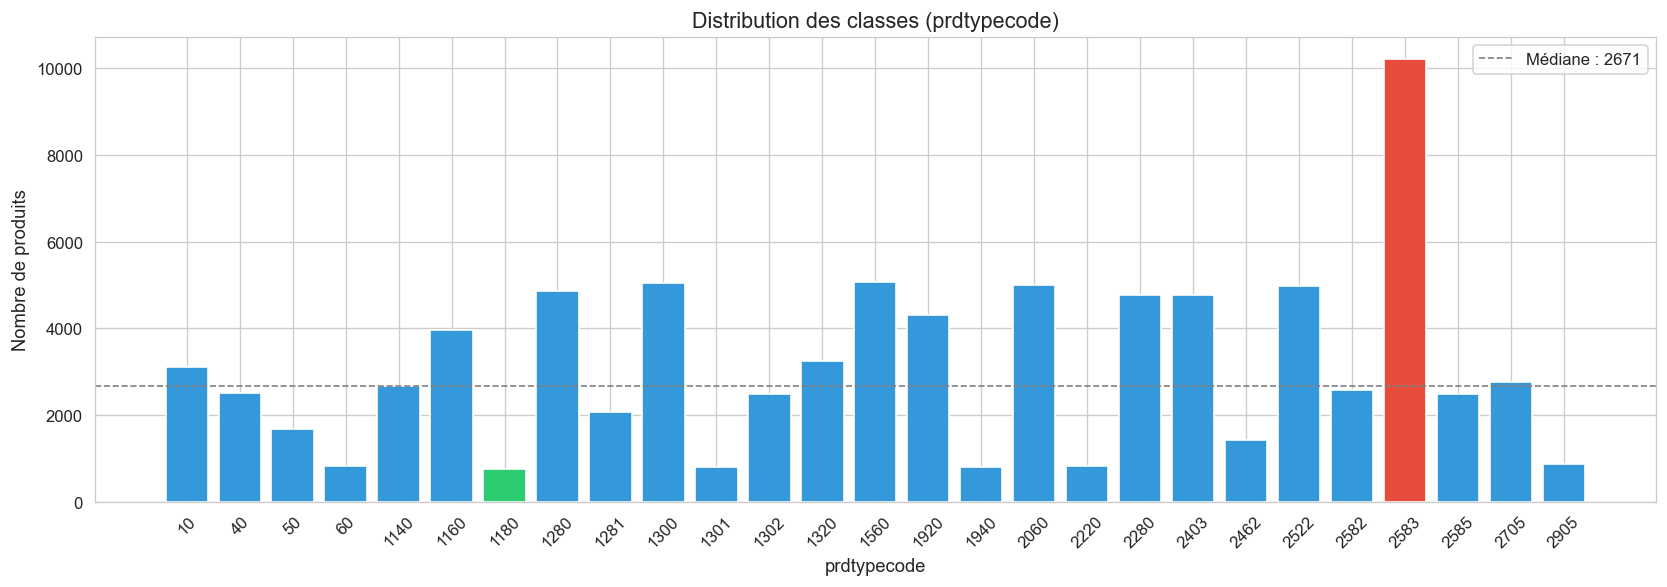

Figure sauvegardée.


In [10]:
# Visualisation de la distribution des classes
fig, ax = plt.subplots(figsize=(14, 5))

colors = ["#e74c3c" if v == class_counts.max() else
          "#2ecc71" if v == class_counts.min() else
          "#3498db" for v in class_counts.values]

ax.bar(class_counts.index.astype(str), class_counts.values, color=colors)
ax.set_xlabel("prdtypecode", fontsize=11)
ax.set_ylabel("Nombre de produits", fontsize=11)
ax.set_title("Distribution des classes (prdtypecode)", fontsize=13)
ax.tick_params(axis="x", rotation=45)

# Ligne médiane
ax.axhline(class_counts.median(), color="gray", linestyle="--", linewidth=1,
           label=f"Médiane : {class_counts.median():.0f}")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01_distribution_classes.png"), dpi=120)
plt.show()
print("Figure sauvegardée.")

### Constat - Distribution des classes

Le dataset contient **27 classes** avec un déséquilibre modéré (ratio max/min : 13.4).
- Classe la plus représentée : **2583** avec 10 209 produits (~12% du dataset).
- Classe la moins représentée : **1180** avec 764 produits (~0.9% du dataset).
- 6 classes sont sous le seuil de 1 000 produits.

Ce déséquilibre justifie le recours au **weighted F1-score** comme métrique principale,
conformément à la métrique officielle du challenge Rakuten.
Il faudra surveiller les performances sur les classes minoritaires lors de la modélisation.

## 5. Analyse des données textuelles

In [11]:
# Statistiques sur la longueur des désignations et descriptions
df["designation_len"]  = df["designation"].str.split().str.len()
df["description_len"]  = df["description"].str.split().str.len()

print("=== Longueur des désignations (en mots) ===")
print(df["designation_len"].describe().round(1))
print()
print("=== Longueur des descriptions (en mots, hors NaN) ===")
print(df["description_len"].describe().round(1))

=== Longueur des désignations (en mots) ===
count    84916.0
mean        11.6
std          6.2
min          3.0
25%          7.0
50%         11.0
75%         14.0
max         56.0
Name: designation_len, dtype: float64

=== Longueur des descriptions (en mots, hors NaN) ===
count    55116.0
mean       123.5
std        123.2
min          1.0
25%         39.0
50%         95.0
75%        161.0
max       2068.0
Name: description_len, dtype: float64


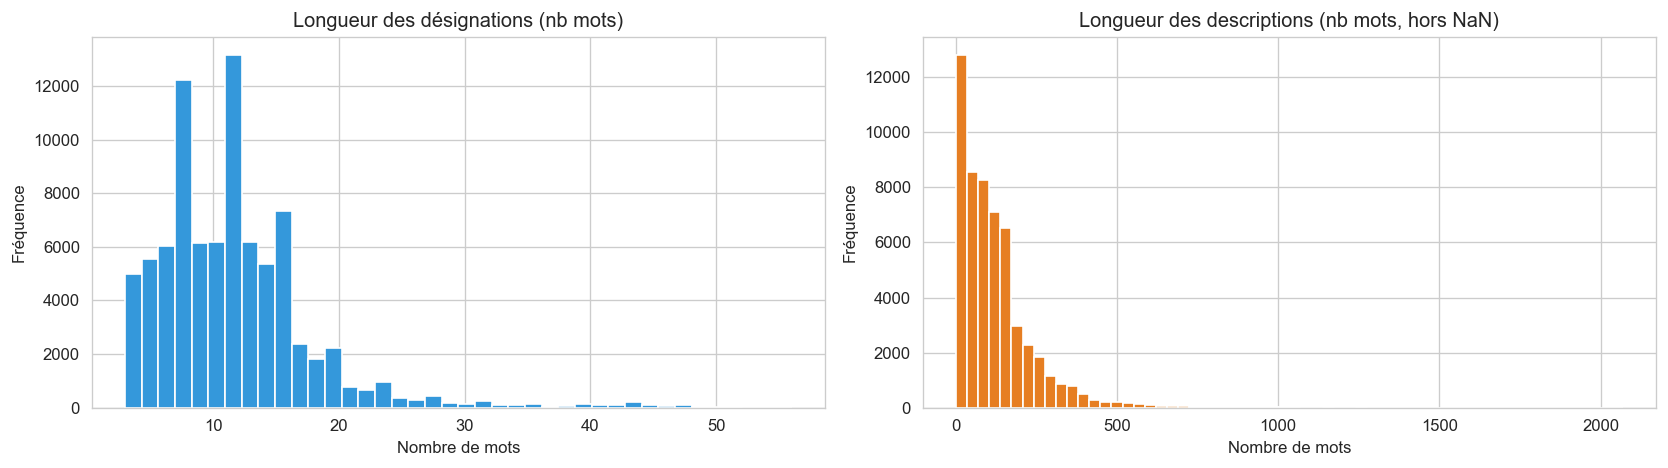

Figure sauvegardée.


In [12]:
# Distribution des longueurs de désignation et description
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["designation_len"], bins=40, color="#3498db", edgecolor="white")
axes[0].set_title("Longueur des désignations (nb mots)")
axes[0].set_xlabel("Nombre de mots")
axes[0].set_ylabel("Fréquence")

axes[1].hist(df["description_len"].dropna(), bins=60, color="#e67e22", edgecolor="white")
axes[1].set_title("Longueur des descriptions (nb mots, hors NaN)")
axes[1].set_xlabel("Nombre de mots")
axes[1].set_ylabel("Fréquence")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "02_longueur_textes.png"), dpi=120)
plt.show()
print("Figure sauvegardée.")

### Constat - Longueur des textes

Les **désignations** sont courtes et homogènes (médiane : 11 mots, max : 56).
Elles constituent une feature textuelle fiable et systématiquement renseignée.

Les **descriptions** sont longues et très hétérogènes (médiane : 95 mots, max : 2068, std : 123).
La distribution est fortement asymétrique à droite : la majorité des descriptions
tient sous 200 mots, mais une queue longue existe.

**Implications pour le preprocessing :**
- La concaténation désignation + description sera tronquée à une longueur maximale fixée
  lors de la modélisation (ex. 512 tokens pour les transformers).
- Les 35% de descriptions manquantes seront remplacées par une chaîne vide
  avant concaténation, pour conserver une colonne texte unifiée sans perte de lignes.

### 5.2 Détection des langues

In [13]:
# Détection de la langue sur la désignation
# Appliqué sur un échantillon stratifié pour limiter le temps de calcul
# La détection sera ensuite validée sur l'ensemble complet

def detect_lang(text):
    try:
        return detect(str(text))
    except LangDetectException:
        return "unknown"

print("Détection de langue en cours (peut prendre 1-2 minutes)...")
tqdm.pandas()
df["lang"] = df["designation"].progress_apply(detect_lang)

print("Terminé.")
print(f"\nDistribution des langues détectées :")
print(df["lang"].value_counts().head(15))

Détection de langue en cours (peut prendre 1-2 minutes)...


100%|██████████| 84916/84916 [06:55<00:00, 204.22it/s]

Terminé.

Distribution des langues détectées :
lang
fr    51725
en    19670
de     5027
nl     2163
ca     1611
it     1125
ro      730
es      524
pt      518
no      271
id      270
af      191
tl      167
da      134
et      110
Name: count, dtype: int64


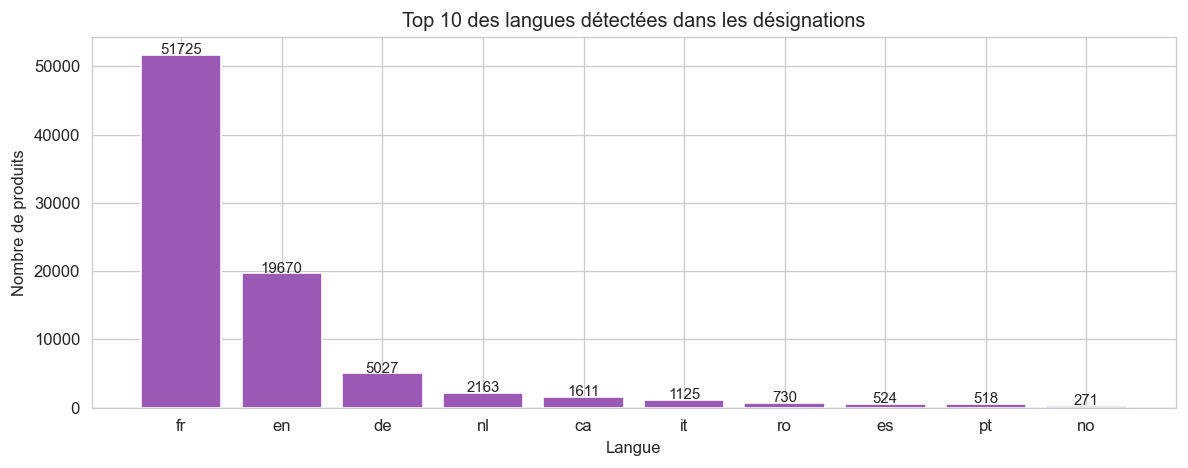

Figure sauvegardée.


In [14]:
# Visualisation de la répartition des langues
lang_counts = df["lang"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lang_counts.index, lang_counts.values, color="#9b59b6", edgecolor="white")
ax.set_title("Top 10 des langues détectées dans les désignations")
ax.set_xlabel("Langue")
ax.set_ylabel("Nombre de produits")

for i, v in enumerate(lang_counts.values):
    ax.text(i, v + 100, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "03_langues_designations.png"), dpi=120)
plt.show()
print("Figure sauvegardée.")

### Constat - Multilinguisme des désignations

Le dataset est **majoritairement francophone** (51 725 produits, ~61%)
mais contient une part significative de textes en d'autres langues :

| Code | Langue       | Nb produits |
|------|--------------|-------------|
| fr   | Français     | 51 725      |
| en   | Anglais      | 19 670      |
| de   | Allemand     |  5 027      |
| nl   | Néerlandais  |  2 163      |
| ca   | Catalan*     |  1 611      |
| it   | Italien      |  1 125      |
| ro   | Roumain      |    730      |
| es   | Espagnol     |    524      |
| pt   | Portugais    |    518      |

*Les codes `ca`, `af`, `tl`, `et` sont probablement des **faux positifs** de détection
sur des désignations courtes ou contenant des termes techniques, des noms propres ou des
références produit ambiguës.

**Implication pour la modélisation :** un modèle d'embedding multilingue
(ex. `paraphrase-multilingual-MiniLM-L12-v2`) est préférable à un modèle
strictement francophone pour couvrir l'ensemble du corpus sans perte d'information.
La colonne `lang` sera conservée comme feature auxiliaire optionnelle.

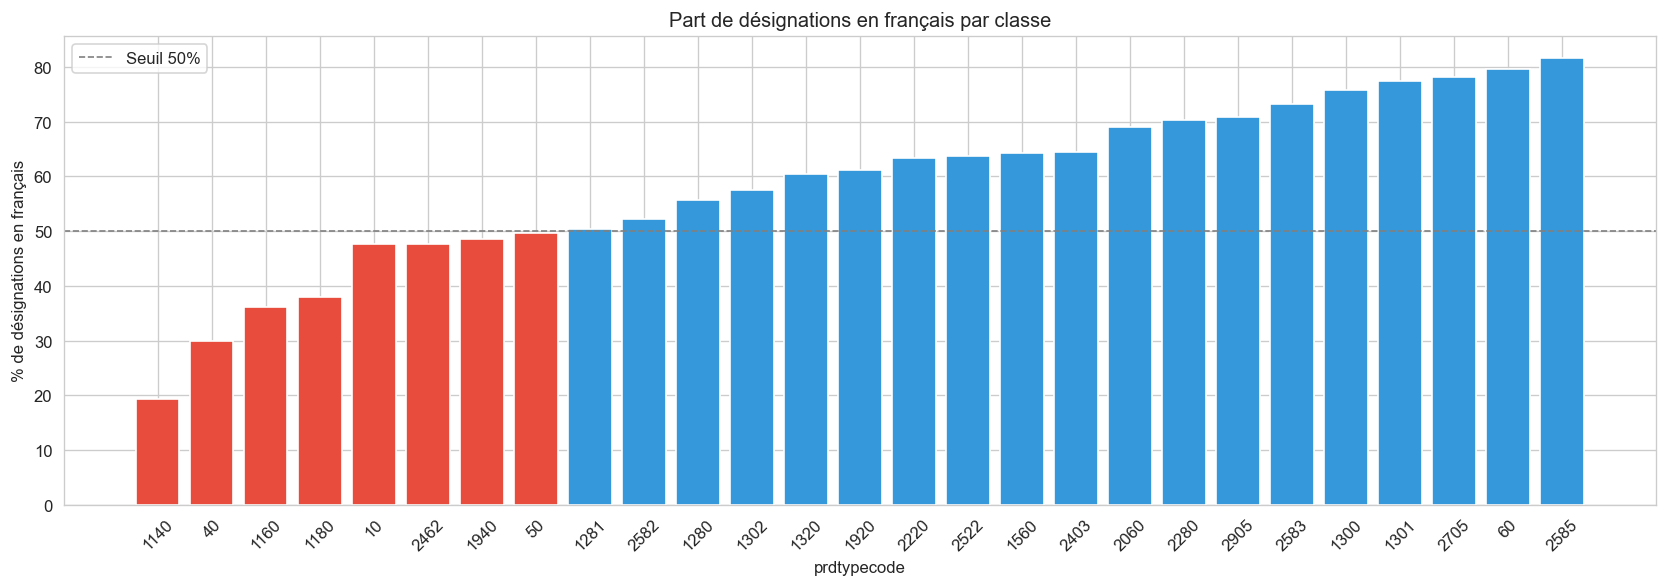

Figure sauvegardée.


In [15]:
# Répartition langue française vs non-française par classe
df["is_french"] = df["lang"] == "fr"

lang_by_class = df.groupby("prdtypecode")["is_french"].mean().sort_values()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#e74c3c" if v < 0.5 else "#3498db" for v in lang_by_class.values]
ax.bar(lang_by_class.index.astype(str), lang_by_class.values * 100, color=colors)
ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="Seuil 50%")
ax.set_xlabel("prdtypecode")
ax.set_ylabel("% de désignations en français")
ax.set_title("Part de désignations en français par classe")
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "04_langue_par_classe.png"), dpi=120)
plt.show()
print("Figure sauvegardée.")

### Constat - Multilinguisme différencié par classe

Toutes les classes ne sont pas égales face au multilinguisme.
6 classes affichent moins de 50% de désignations en français (en rouge sur le graphique) :
- **1140** (~20% fr) : très fortement anglophone ou germanophone.
- **40, 1160, 1180, 10, 2462** : entre 30% et 50% de français.

À l'inverse, les classes **60, 2585, 2705, 1301** dépassent 75% de français.

**Implication directe :** un modèle NLP monolingue français manquerait une part significative
du signal dans les classes 1140, 40 et 1160. Un modèle multilingue de type
`paraphrase-multilingual-MiniLM-L12-v2` est donc indispensable pour couvrir
uniformément toutes les classes sans biais linguistique.

### 5.3 Analyse du taux de description renseignée par classe

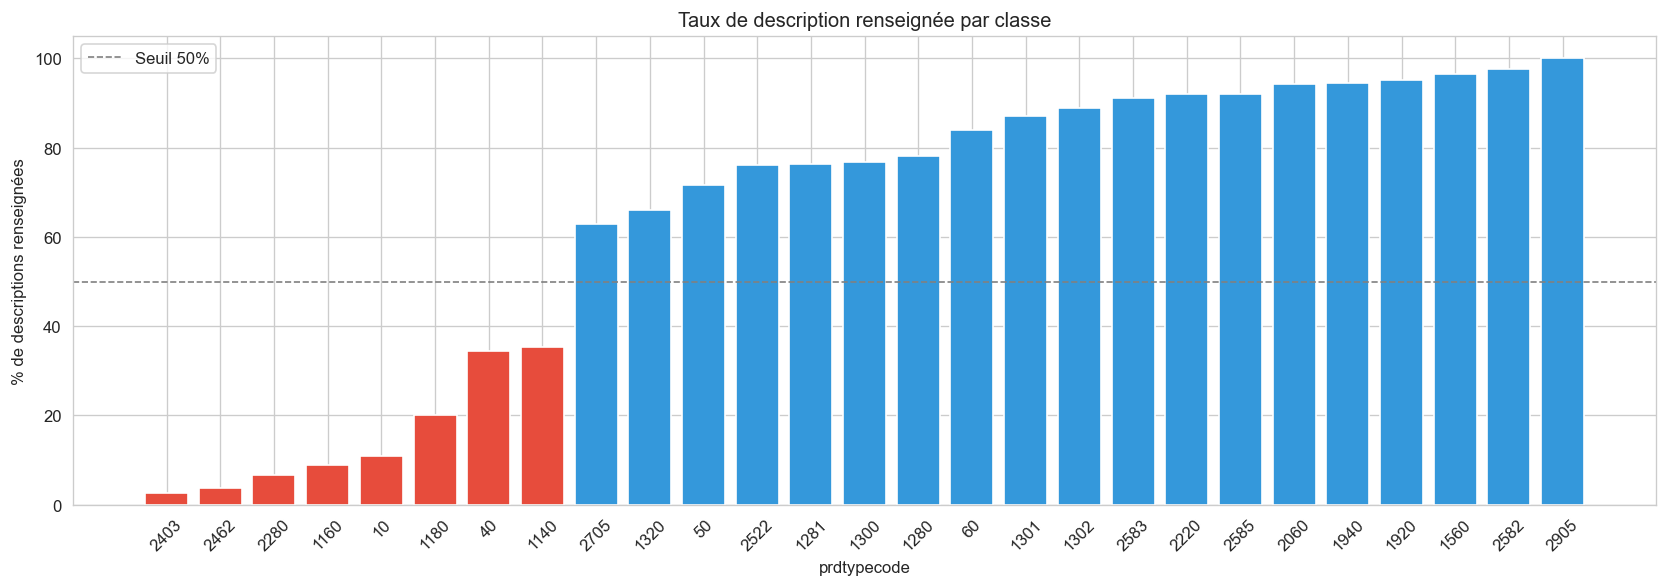

Taux de description renseignée par classe :
prdtypecode
2403      2.6
2462      3.7
2280      6.7
1160      8.8
10       10.8
1180     20.0
40       34.5
1140     35.4
2705     62.9
1320     66.0
50       71.7
2522     76.2
1281     76.2
1300     76.7
1280     78.1
60       84.0
1301     87.0
1302     88.9
2583     91.2
2220     92.0
2585     92.1
2060     94.3
1940     94.4
1920     95.2
1560     96.5
2582     97.6
2905    100.0


In [16]:
# Taux de description renseignée par classe
desc_rate = df.groupby("prdtypecode")["description"].apply(
    lambda x: x.notna().mean() * 100
).sort_values()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#e74c3c" if v < 50 else "#3498db" for v in desc_rate.values]
ax.bar(desc_rate.index.astype(str), desc_rate.values, color=colors)
ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="Seuil 50%")
ax.set_xlabel("prdtypecode")
ax.set_ylabel("% de descriptions renseignées")
ax.set_title("Taux de description renseignée par classe")
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "05_description_par_classe.png"), dpi=120)
plt.show()

print("Taux de description renseignée par classe :")
print(desc_rate.round(1).to_string())

### Constat - Taux de description très hétérogène selon les classes

Le taux de description renseignée varie de **2.6% (classe 2403)** à **100% (classe 2905)**.

5 classes ont moins de 10% de descriptions disponibles :
- **2403** : 2.6%, **2462** : 3.7%, **2280** : 6.7%, **1160** : 8.8%, **10** : 10.8%

Ces classes devront s'appuyer quasi exclusivement sur la **désignation et l'image**.

À l'inverse, 10 classes dépassent 90% de descriptions renseignées,
pour lesquelles la concaténation désignation + description apportera un signal textuel riche.

**Implication pour le preprocessing :** la stratégie de remplacement des NaN
par une chaîne vide est confirmée. Il n'est pas pertinent d'imputer les descriptions
manquantes par une valeur synthétique, car leur absence est structurelle
et non aléatoire : elle est corrélée à la classe du produit.

## 6. Exploration des images

In [17]:
# Vérification de la disponibilité des images et affichage d'exemples par classe
import random

# Construction du nom de fichier image à partir de imageid et productid
def get_image_path(row):
    return os.path.join(
        IMAGE_TRAIN_DIR,
        f"image_{row['imageid']}_product_{row['productid']}.jpg")

df["image_path"] = df.apply(get_image_path, axis=1)

# Vérification de l'existence des fichiers
df["image_exists"] = df["image_path"].apply(os.path.exists)

print(f"Images trouvées     : {df['image_exists'].sum()}")
print(f"Images manquantes   : {(~df['image_exists']).sum()}")
print(f"Taux de couverture  : {df['image_exists'].mean()*100:.1f}%")

Images trouvées     : 84916
Images manquantes   : 0
Taux de couverture  : 100.0%


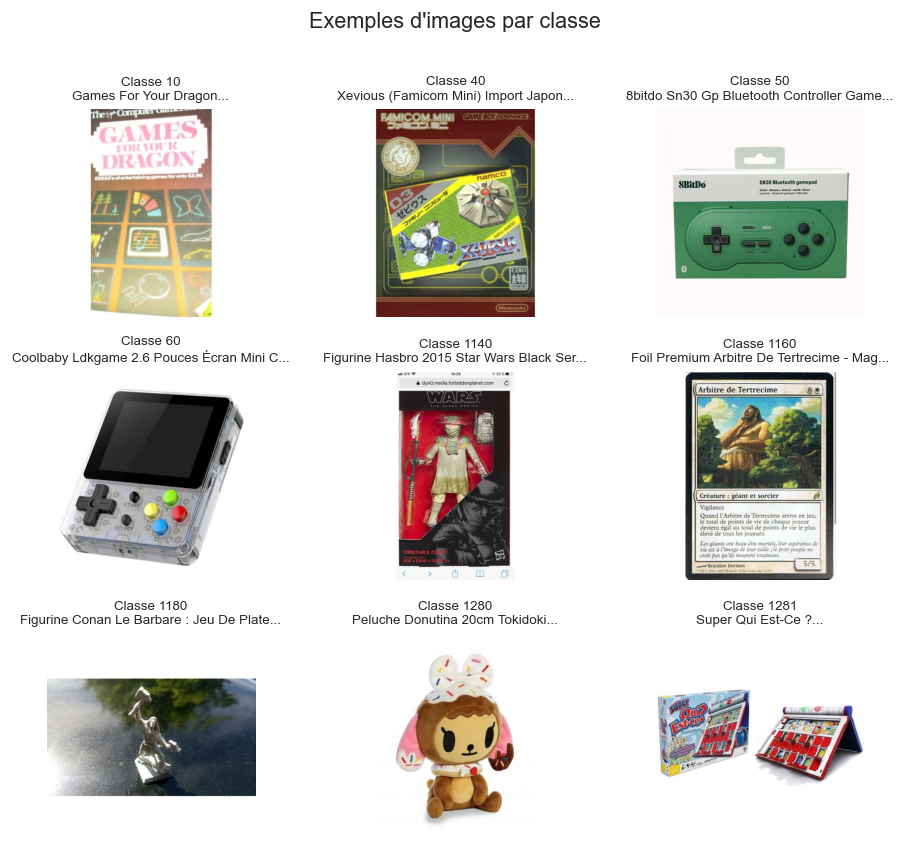

Figure sauvegardée.


In [23]:
# Affichage de quelques exemples d'images par classe
classes_sample = sorted(df["prdtypecode"].unique())[:9]

fig, axes = plt.subplots(3, 3, figsize=(8, 7))
axes = axes.flatten()

for i, cls in enumerate(classes_sample):
    subset = df[(df["prdtypecode"] == cls) & (df["image_exists"])]
    if len(subset) == 0:
        continue
    row = subset.sample(1).iloc[0]
    try:
        img = Image.open(row["image_path"]).convert("RGB")
        axes[i].imshow(img)
        axes[i].set_title(f"Classe {cls}\n{row['designation'][:40]}...", fontsize=8)
        axes[i].axis("off")
    except Exception:
        axes[i].set_title(f"Classe {cls} — image illisible")
        axes[i].axis("off")

plt.suptitle("Exemples d'images par classe", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "06_exemples_images_classes.png"),
            dpi=120, bbox_inches="tight")
plt.show()
print("Figure sauvegardée.")

### Constat - Couverture et pertinence des images

La couverture image est **totale : 84 916 images disponibles sur 84 916 produits**.
Aucune donnée image n'est manquante, contrairement à la description textuelle.

Les exemples visuels illustrent une **forte séparabilité inter-classes** :
- Classe 10 : couvertures de livres et BD
- Classes 40, 50, 60 : périphériques et manettes de jeux vidéo
- Classe 1140 : figurines de collection
- Classe 1160 : cartes à jouer (Yu-Gi-Oh, Pokémon, etc.)
- Classes 1280, 1281 : jouets et jeux pour enfants

L'image constitue donc une feature **complémentaire et robuste** :
disponible sur 100% des produits, visuellement discriminante entre classes,
et capable de lever les ambiguïtés que le texte seul ne peut résoudre.

## 7. Preprocessing

### 7.1 Preprocessing textuel

In [24]:
import unicodedata

# Fonction de nettoyage texte
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    # Suppression des entités HTML (ex: &eacute; &amp;)
    text = re.sub(r"&[a-zA-Z]+;", " ", text)
    # Suppression des balises HTML résiduelles
    text = re.sub(r"<[^>]+>", " ", text)
    # Normalisation unicode (accents)
    text = unicodedata.normalize("NFKD", text)
    # Suppression des caractères non-alphabétiques sauf espaces
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", text)
    # Normalisation des espaces
    text = re.sub(r"\s+", " ", text).strip()
    # Mise en minuscules
    text = text.lower()
    return text

# Application sur désignation et description
df["designation_clean"]  = df["designation"].apply(clean_text)
df["description_clean"]  = df["description"].apply(clean_text)

# Concaténation en une colonne texte unifiée
# La description est vide ("") quand NaN, donc la concat est propre
df["text_combined"] = (
    df["designation_clean"] + " " + df["description_clean"]
).str.strip()

# Vérification
print("Exemples de texte nettoyé :")
for i in [0, 2, 4]:
    print(f"\n[{i}] designation_clean : {df['designation_clean'].iloc[i][:80]}")
    print(f"[{i}] text_combined     : {df['text_combined'].iloc[i][:120]}")

Exemples de texte nettoyé :

[0] designation_clean : olivia personalisiertes notizbuch seiten punktraster ca din a rosen design
[0] text_combined     : olivia personalisiertes notizbuch seiten punktraster ca din a rosen design

[2] designation_clean : grand stylet ergonomique bleu gamepad nintendo wii u speedlink pilot style
[2] text_combined     : grand stylet ergonomique bleu gamepad nintendo wii u speedlink pilot style pilot style touch pen de marque speedlink est

[4] designation_clean : la guerre des tuques
[4] text_combined     : la guerre des tuques luc a des id es de grandeur il veut organiser un jeu de guerre de boules de neige et s arranger pou


In [25]:
# Vérification : aucune valeur vide après nettoyage sur designation
vides_designation = (df["designation_clean"].str.strip() == "").sum()
vides_combined    = (df["text_combined"].str.strip() == "").sum()

print(f"Désignations vides après nettoyage : {vides_designation}")
print(f"Textes combinés vides après nettoyage : {vides_combined}")
print(f"\nLongueur moyenne text_combined (mots) : "
      f"{df['text_combined'].str.split().str.len().mean():.1f}")

Désignations vides après nettoyage : 0
Textes combinés vides après nettoyage : 0

Longueur moyenne text_combined (mots) : 97.1


### Constat - Preprocessing textuel

Le nettoyage produit **0 texte vide** sur 84 916 produits.
Les opérations appliquées sont : suppression des entités HTML, des balises résiduelles,
normalisation unicode, suppression des caractères non-alphabétiques, mise en minuscules.

La colonne `text_combined` (désignation + description nettoyées) sera la feature
textuelle principale pour la modélisation. Sa longueur moyenne est de **97.1 mots**,
ce qui est compatible avec les fenêtres contextuelles des modèles transformers (512 tokens).

### 7.2 Preprocessing image

In [27]:
# Vérification des dimensions et modes des images sur un échantillon
sample_paths = df[df["image_exists"]].sample(500, random_state=42)["image_path"].tolist()

widths, heights, modes = [], [], []

for path in tqdm(sample_paths, desc="Analyse images"):
    try:
        with Image.open(path) as img:
            widths.append(img.width)
            heights.append(img.height)
            modes.append(img.mode)
    except Exception:
        pass

print(f"Largeur  - min: {min(widths)}, max: {max(widths)}, "
      f"médiane: {int(np.median(widths))}")
print(f"Hauteur  - min: {min(heights)}, max: {max(heights)}, "
      f"médiane: {int(np.median(heights))}")
print(f"\nModes couleur :")
from collections import Counter
for mode, count in Counter(modes).most_common():
    print(f"  {mode} : {count}")

Analyse images: 100%|██████████| 500/500 [00:00<00:00, 10842.48it/s]

Largeur  - min: 500, max: 500, médiane: 500
Hauteur  - min: 500, max: 500, médiane: 500

Modes couleur :
  RGB : 500


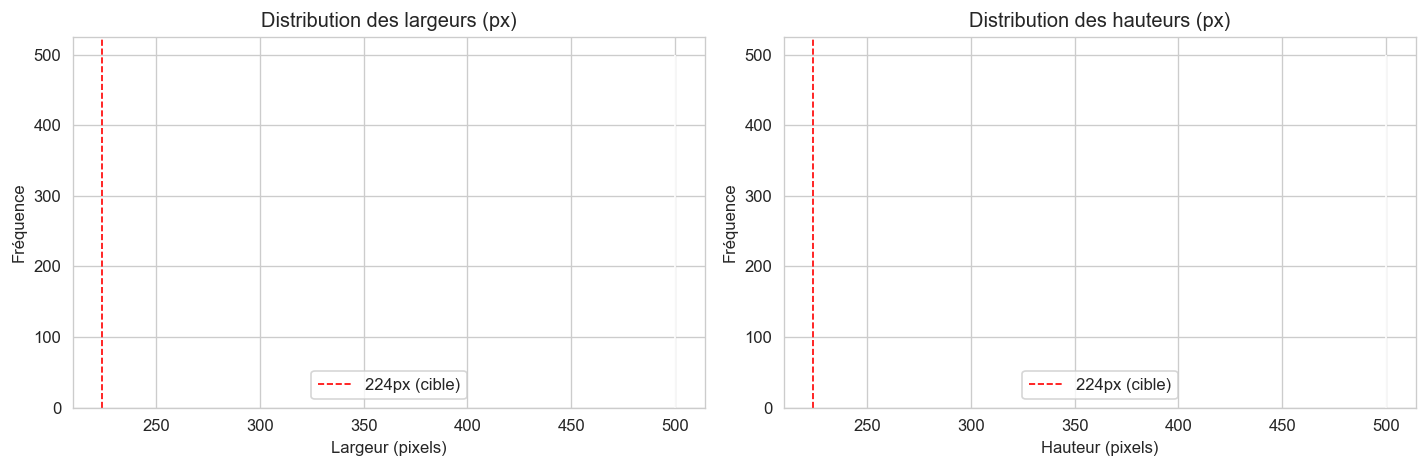

Figure sauvegardée.


In [28]:
# Distribution des dimensions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(widths, bins=40, color="#1abc9c", edgecolor="white")
axes[0].set_title("Distribution des largeurs (px)")
axes[0].set_xlabel("Largeur (pixels)")
axes[0].set_ylabel("Fréquence")
axes[0].axvline(224, color="red", linestyle="--", linewidth=1, label="224px (cible)")
axes[0].legend()

axes[1].hist(heights, bins=40, color="#e67e22", edgecolor="white")
axes[1].set_title("Distribution des hauteurs (px)")
axes[1].set_xlabel("Hauteur (pixels)")
axes[1].set_ylabel("Fréquence")
axes[1].axvline(224, color="red", linestyle="--", linewidth=1, label="224px (cible)")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "07_dimensions_images.png"), dpi=120)
plt.show()
print("Figure sauvegardée.")

In [29]:
# Définition du pipeline de preprocessing image
# Paramètres cibles pour les modèles de transfer learning (ResNet, VGG, EfficientNet)
IMAGE_SIZE    = (224, 224)
IMAGE_MEAN    = [0.485, 0.456, 0.406]  # Moyenne ImageNet (RGB)
IMAGE_STD     = [0.229, 0.224, 0.225]  # Écart-type ImageNet (RGB)

def preprocess_image(image_path, target_size=IMAGE_SIZE):
    """
    Charge une image, la redimensionne en target_size,
    la convertit en RGB et retourne un array normalisé [0,1].
    Retourne None si l'image est illisible.
    """
    try:
        with Image.open(image_path) as img:
            img = img.convert("RGB")
            img = img.resize(target_size, Image.LANCZOS)
            arr = np.array(img) / 255.0
            return arr
    except Exception:
        return None

# Test sur un exemple
test_path = df[df["image_exists"]].iloc[2]["image_path"]
test_arr  = preprocess_image(test_path)

print(f"Shape après preprocessing : {test_arr.shape}")
print(f"Valeurs min/max           : {test_arr.min():.3f} / {test_arr.max():.3f}")
print(f"Dtype                     : {test_arr.dtype}")

Shape après preprocessing : (224, 224, 3)
Valeurs min/max           : 0.180 / 1.000
Dtype                     : float64


### Constat - Preprocessing image

Toutes les images du dataset sont **uniformément 500x500 pixels en mode RGB**.
Aucune variabilité de dimensions, aucune image en niveaux de gris ou CMJN.
C'est une propriété exceptionnelle qui simplifie considérablement le pipeline image.

Le preprocessing appliqué est :
1. Conversion en RGB (déjà le cas pour toutes les images).
2. Redimensionnement à **224x224 pixels** via interpolation LANCZOS.
3. Normalisation des valeurs dans **[0, 1]**.

La normalisation ImageNet (soustraction de la moyenne et division par l'écart-type
par canal RGB) sera appliquée directement dans le pipeline de modélisation,
au moment du chargement par batch, et non à ce stade.

## 8. Export du dataset préprocessé

In [30]:
# Sélection des colonnes utiles pour la modélisation
cols_to_save = [
    "designation",
    "description",
    "designation_clean",
    "description_clean",
    "text_combined",
    "productid",
    "imageid",
    "image_path",
    "lang",
    "prdtypecode"]

df_processed = df[cols_to_save].copy()

# Export
output_path = os.path.join(DATA_PROC_DIR, "df_train_processed.csv")
df_processed.to_csv(output_path, index=True)

print(f"Dataset exporté : {output_path}")
print(f"Shape           : {df_processed.shape}")
print(f"\nAperçu des colonnes exportées :")
print(df_processed.dtypes)

Dataset exporté : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\processed\df_train_processed.csv
Shape           : (84916, 10)

Aperçu des colonnes exportées :
designation          object
description          object
designation_clean    object
description_clean    object
text_combined        object
productid             int64
imageid               int64
image_path           object
lang                 object
prdtypecode           int64
dtype: object


## 9. Synthèse et conclusions pour la modélisation

### Récapitulatif des constats clés

| Dimension | Constat | Implication modélisation |
|-----------|---------|--------------------------|
| Volume | 84 916 produits, 27 classes | Dataset suffisant pour le deep learning |
| Déséquilibre | Ratio max/min 13.4 (2583 vs 1180) | Weighted F1-score comme métrique principale |
| Description | 35% de NaN, hétérogène par classe | Remplacement NaN par "", concaténation avec désignation |
| Multilinguisme | 61% fr, 23% en, 6% de, 10 autres langues | Modèle multilingue indispensable (ex. multilingual-MiniLM) |
| Images | 100% disponibles, 500x500 RGB uniformes | Pipeline image standardisé, resize 224x224 |
| Ambiguïté texte | 145 désignations identiques, classes différentes | L'image est nécessaire pour lever certaines ambiguïtés |
| Classes multilingues | 1140, 40, 1160 < 50% de français | Modèle monolingue français insuffisant |

### Stratégie de modélisation recommandée

**Approche baseline (Rendu 2 - étape 1)**
- TF-IDF sur `text_combined` + Logistic Regression ou LinearSVC.
- Objectif : établir un score de référence interne avant deep learning.

**Approche deep learning texte**
- Modèle multilingue sentence-transformers (`paraphrase-multilingual-MiniLM-L12-v2`).
- Fine-tuning ou extraction d'embeddings + classifieur.

**Approche deep learning image**
- Transfer learning ResNet50 (aligné sur le benchmark Rakuten).
- Fine-tuning des dernières couches.

**Approche multimodale**
- Fusion tardive (late fusion) des embeddings texte et image.
- Concaténation des vecteurs + couche de classification.